# 📸 ViT-GPT2 Image Captioning - Complete Fine-tuning and Evaluation Pipeline

This notebook trains a captioning model using ViT as the image encoder and GPT2 as the decoder, evaluated on Flickr8k dataset with COCO metrics.

In [1]:
#
# -------------------------------------------------------------------------------------------------
# 0. DYNAMIC MODE: DEPLOYMENT OR TRAINING
# -------------------------------------------------------------------------------------------------
#
import os
import sys
import subprocess

# Define the name of the file that triggers deployment mode
DEPLOYMENT_BUNDLE_FILE = "streamlit_app_bundle.zip"

if os.path.exists(DEPLOYMENT_BUNDLE_FILE):
    print("✅ Deployment bundle found! Entering DEPLOYMENT MODE.")
    print("   - All subsequent cells will be skipped.")

    # --- 1. Unpack the application files ---
    print("\n[1/3] Unpacking model and application files...")
    !unzip -q {DEPLOYMENT_BUNDLE_FILE}
    print("   - Unzip complete.")

    # --- 2. Install necessary libraries for deployment ---
    print("\n[2/3] Installing Streamlit, Transformers, and ngrok...")
    #!pip install -q streamlit transformers torch pyngrok
    #!pip install -q streamlit transformers torch pyngrok --ignore-installed blinker
    """!pip install -q fsspec==2025.3.0
    !pip install -q \
        "streamlit" \
        "torch==2.3.1" \
        "pyngrok" \
        "transformers==4.41.2" \
        "tokenizers==0.19.1" \
        --ignore-installed blinker"""
    print("   - Installation complete.")
    print("   - Installation complete.")

    # --- 3. Launch the Streamlit App via ngrok ---
    print("\n[3/3] Launching Streamlit application...")
    from pyngrok import ngrok

    #app_script_path = "app.py"
    #!streamlit run {app_script_path} --server.port 8501
    # FIX: Use 'python -m streamlit' to ensure the command is found
    command = "python -m streamlit run app.py --server.port 8501"
    
    with open("streamlit.log", "w") as log_file:
        process = subprocess.Popen(command, shell=True, stdout=log_file, stderr=log_file)

    # It's recommended to add your ngrok authtoken for stable connections
    # You can get one from https://dashboard.ngrok.com/get-started/your-authtoken
    ngrok.set_auth_token("30NaXVpu6lV0anJnCB29AlhnMs9_3ftnJV5rnB5sE7EbBeowj")    
    public_url = ngrok.connect(8501)

    print("🚀 Your Streamlit app is live!")
    print(f"👉 Click here to open: {public_url}")

    # Stop the notebook execution so it doesn't proceed to training
    sys.exit()

else:
    print(""")
    ##################################################################################
    # 🚀 No deployment bundle found. Entering FULL TRAINING MODE.                    #
    # The notebook will now proceed to download data and train a new model from scratch. #
    ##################################################################################
    """)

✅ Deployment bundle found! Entering DEPLOYMENT MODE.
   - All subsequent cells will be skipped.

[1/3] Unpacking model and application files...
/bin/bash: line 1: unzip: command not found


   - Unzip complete.

[2/3] Installing Streamlit, Transformers, and ngrok...

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
   - Installation complete.
   - Installation complete.

[3/3] Launching Streamlit application...
🚀 Your Streamlit app is live!
👉 Click here to open: NgrokTunnel: "https://2329b0c6d486.ngrok-free.app" -> "http://localhost:8501"


SystemExit: 

/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
#
# -------------------------------------------------------------------------------------------------
# 0. DYNAMIC MODE: DEPLOYMENT OR TRAINING (Google Colab Version)
# -------------------------------------------------------------------------------------------------
#
import os
import sys
from google.colab import drive

# --- 1. Mount Google Drive ---
print("📁 Mounting Google Drive...")
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully.")

# --- 2. Check for Deployment Bundle in Google Drive ---
# Define the path to the zip file in your Google Drive (assumes it's in the root folder)
drive_bundle_path = "/content/drive/My Drive/Capstone/CaptionGenerator/streamlit_app_bundle.zip"
local_bundle_file = "streamlit_app_bundle.zip"

if os.path.exists(drive_bundle_path):
    print(f"\n✅ Deployment bundle found in Google Drive! Entering DEPLOYMENT MODE.")
    print("   - All subsequent cells will be skipped.")

    # --- 3. Copy the bundle from Drive to the local Colab environment ---
    print(f"\n[1/4] Copying '{os.path.basename(drive_bundle_path)}' from Google Drive...")
    !cp "{drive_bundle_path}" .
    print("   - Copy complete.")

    # --- 4. Unpack the application files ---
    print("\n[2/4] Unpacking model and application files...")
    !unzip -q {local_bundle_file}
    print("   - Unzip complete.")

    # --- 5. Install necessary libraries for deployment ---
    print("\n[3/4] Installing Streamlit, Transformers, and ngrok...")
    !pip install -q streamlit transformers torch pyngrok
    print("   - Installation complete.")

    # --- 6. Launch the Streamlit App via ngrok ---
    print("\n[4/4] Launching Streamlit application...")
    from pyngrok import ngrok

    app_script_path = "app.py"
    !streamlit run {app_script_path} --server.port 8501 &

    # It's recommended to add your ngrok authtoken for stable connections
    # You can get one from https://dashboard.ngrok.com/get-started/your-authtoken
    ngrok.set_auth_token("30NaXVpu6lV0anJnCB29AlhnMs9_3ftnJV5rnB5sE7EbBeowj")

    public_url = ngrok.connect(8501)

    print("🚀 Your Streamlit app is live!")
    print(f"👉 Click here to open: {public_url}")

    # Stop the notebook execution so it doesn't proceed to training
    sys.exit()

else:
    print(f"\n❌ Deployment bundle not found at '{drive_bundle_path}'.")
    print("""
    ##################################################################################
    # 🚀 Entering FULL TRAINING MODE.                                                 #
    # The notebook will now proceed to train a new model from scratch.                 #
    ##################################################################################
    """)

📁 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully.

✅ Deployment bundle found in Google Drive! Entering DEPLOYMENT MODE.
   - All subsequent cells will be skipped.

[1/4] Copying 'streamlit_app_bundle.zip' from Google Drive...
   - Copy complete.

[2/4] Unpacking model and application files...
replace streamlit_app_model/preprocessor_config.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
   - Unzip complete.

[3/4] Installing Streamlit, Transformers, and ngrok...
   - Installation complete.

[4/4] Launching Streamlit application...



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.13.179:8501

2025-07-26 10:32:03.224157: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register

SystemExit: 

In [4]:
!streamlit run app.py --server.port 8501 &




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.13.179:8501

2025-07-26 10:48:09.572741: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753526889.596871    8847 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753526889.604163    8847 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-26 10:48:09.630110: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations

In [2]:
#
# -------------------------------------------------------------------------------------------------
# 1. SETUP AND INSTALLATIONS
# -------------------------------------------------------------------------------------------------
#
# ✅ Package Installation for RunPod (CUDA 12.4, Torch 2.6.0)
!pip install -q --upgrade pip

#Install Java, which is required for CIDEr and SPICE metrics ---
!apt-get install -y -q default-jdk

# Install the 'unzip' utility
!apt-get install -y -q unzip

!pip install -q gdown
!pip install -q \
    tqdm==4.66.4 \
    transformers==4.42.1 datasets==2.19.1 tokenizers==0.19.1 accelerate==0.30.1 \
    huggingface_hub==0.23.0 sentencepiece==0.2.0 \
    evaluate==0.4.2 nltk==3.8.1 rouge-score==0.1.2 \
    "wandb>=0.15.0" \
    Pillow==10.3.0 opencv-python==4.9.0.80 scikit-image==0.22.0 \
    matplotlib==3.9.0 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 scikit-learn==1.5.0 \
    ipykernel==6.29.4 ipywidgets==8.1.2
# pycocoevalcap (GitHub only)
!pip install git+https://github.com/salaniz/pycocoevalcap.git
!pip install evaluate
!pip install -q  streamlit pycocotools pycocoevalcap requests
!apt-get update && apt-get install -y openjdk-8-jre-headless zip


Reading package lists...
Building dependency tree...
Reading state information...
E: Unable to locate package default-jdk
Reading package lists...
Building dependency tree...
Reading state information...
E: Unable to locate package unzip
ERROR: Cannot install huggingface_hub==0.23.0 and transformers==4.42.1 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts
  Cloning https://github.com/salaniz/pycocoevalcap.git to /tmp/pip-req-build-4h0ilusx
  Running command git clone --filter=blob:none --quiet https://github.com/salaniz/pycocoevalcap.git /tmp/pip-req-build-4h0ilusx
  Resolved https://github.com/salaniz/pycocoevalcap.git to commit a24f74c408c918f1f4ec34e9514bc8a76ce41ffd
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'pycocoevalcap' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future versio

error: uninstall-distutils-installed-package

× Cannot uninstall blinker 1.4
╰─> It is a distutils installed project and thus we cannot accurately determine which files belong to it which would lead to only a partial uninstall.
Get:1 http://archive.ubuntu.com/ubuntu jammy InRelease [270 kB]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1581 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:4 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy/restricted amd64 Packages [164 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy/main amd64 Packages [1792 kB]     
Get:9 http://archive.ubuntu.com/ubuntu jammy/multiverse amd64 Packages [266 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy/

In [3]:
# Install necessary packages with corrected dependencies
!pip install -q --upgrade pip
#!pip install -q "torch==2.6.0" "torchvision==0.19.0" "torchaudio==2.6.0" --index-url https://download.pytorch.org/whl/cu121
!pip install -q \
    "transformers==4.42.1" \
    "datasets>=2.19.0" \
    "tokenizers>=0.19.0" \
    "accelerate>=0.30.0" \
    "huggingface_hub" \
    "evaluate>=0.4.2" \
    "nltk>=3.8.1" \
    "rouge-score>=0.1.2" \
    "sentencepiece>=0.2.0" \
    "Pillow>=10.3.0" \
    "pandas>=2.2.2"
!pip install -q git+https://github.com/salaniz/pycocoevalcap.git
!pip install matplotlib seaborn numpy wandb

print("\n✅ All dependencies installed successfully.")

print("\n" + "="*60)
print("🔥 CRITICAL: You MUST restart the kernel for changes to take effect.")


✅ All dependencies installed successfully.

🔥 CRITICAL: You MUST restart the kernel for changes to take effect.


In [1]:
import os
import json
import random
import requests
import numpy as np
import torch
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import json
import random
import re
import subprocess
import shutil
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import requests  # <--- ADD THIS LINE
from tqdm.auto import tqdm

import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from datasets import load_dataset, DatasetDict, Dataset
from evaluate import load
from transformers import (ViTModel, ViTImageProcessor, GPT2Tokenizer, GPT2LMHeadModel,
                          Seq2SeqTrainer, Seq2SeqTrainingArguments, TrainerCallback)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pkg_resources
import sys
import torch

# List of packages to check
packages = [
    'transformers',
    'datasets',
    'torch',
    'torchvision',
    'streamlit',
    'pycocotools',
    'pycocoevalcap',
    'pandas',
    'numpy',
    'pillow',  # PIL is part of pillow
    'tqdm',
    'matplotlib',
]

# Print Python version
print(f"Python version: {sys.version.split()[0]}")

# Print package versions
for package in packages:
    try:
        version = pkg_resources.get_distribution(package).version
        print(f"{package}: {version}")
    except pkg_resources.DistributionNotFound:
        print(f"{package}: Not installed")

print("\n"+torch.cuda.get_device_name(0))
print("CUDA available:", torch.cuda.is_available())
print("PyTorch detects CUDA:", torch.version.cuda)

from importlib.metadata import version
print("Blinker:", version("blinker"))

/tmp/ipykernel_15129/1252738218.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Python version: 3.10.12
transformers: 4.42.1
datasets: 4.0.0
torch: 2.3.1
torchvision: Not installed
streamlit: 1.47.1
pycocotools: 2.0.10
pycocoevalcap: 1.2
pandas: 2.3.1
numpy: 1.26.4
pillow: 11.3.0
tqdm: 4.67.1
matplotlib: 3.10.3

NVIDIA RTX A5000
CUDA available: True
PyTorch detects CUDA: 12.1
Blinker: 1.9.0


In [3]:
#
# -------------------------------------------------------------------------------------------------
# 2. CONFIGURATION AND PATHS
# -------------------------------------------------------------------------------------------------
#
import wandb
class BaseCFG:
    """Base configuration settings for the experiment."""
    # --- Experiment Switches ---
    dataset_name = "flickr8k"  # Can be "flickr8k" or "flickr30k"
    force_model_retrain = False # <-- FIX: Re-added the missing attribute

    # --- Directory Config ---
    base_dir = "./"

    # --- WandB Config ---
    wandb_project = "Image_Captioning_ViT-GPT2"
    WANDB_API_KEY = "7bbf7dc1d29a93c3cd9e115741e377d149f63ee7"
    WANDB_MODE = "online" # Supported values: "online", "disabled"

    # --- Model Config ---
    encoder_name = "google/vit-base-patch16-224-in21k"
    decoder_name = "gpt2"

    # --- Training Config ---
    epochs = 15
    early_stopping_patience = 3
    train_batch_size = 8
    eval_batch_size = 8
    max_length = 40
    seed = 42

cfg = BaseCFG()

def seed_everything(seed=42):
    """Set seeds for reproducibility."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def generate_paths(base_path, dataset_name, cfg):
    """Generates and creates all necessary directory paths for an experiment."""
    # Create a unique name for the model based on its components
    model_combo_name = f"{dataset_name}_{cfg.encoder_name.replace('/', '-')}_{cfg.decoder_name.replace('/', '-')}"

    paths = {
        "dataset_name": dataset_name,
        "dataset_dir": os.path.join(base_path, "data", dataset_name),
        "image_dir": os.path.join(base_path, "data", dataset_name, "Images"),
        "captions_file": os.path.join(base_path, "data", dataset_name, f"{dataset_name}_captions.csv"),
        "results_dir": os.path.join(base_path, "results", model_combo_name),
        "checkpoint_dir": os.path.join(base_path, "checkpoints", model_combo_name),
        "experiment_name": model_combo_name # <-- FIX: Re-added the missing key
    }

    # Create the necessary directories
    for path_key in ["dataset_dir", "results_dir", "checkpoint_dir"]:
        os.makedirs(paths[path_key], exist_ok=True)

    return paths

# Initialize Config and Paths
cfg = BaseCFG()
paths = generate_paths(cfg.base_dir, cfg.dataset_name, cfg)
seed_everything(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
#
# -------------------------------------------------------------------------------------------------
# 3. WEIGHTS & BIASES LOGIN
# -------------------------------------------------------------------------------------------------
#
# Login to Weights & Biases
# Handles logging into the WandB service for experiment tracking.
wandb_api_key = os.environ.get("WANDB_API_KEY") or BaseCFG.WANDB_API_KEY
try:
    if wandb_api_key and wandb_api_key != "PASTE_YOUR_WANDB_API_KEY_HERE":
        print("Logging into WandB using API key.")
        wandb.login(key=wandb_api_key)
    else:
        print("WandB API Key not found or is placeholder. Attempting interactive login.")
        wandb.login()
except Exception as e:
    print(f"Could not log in to WandB: {e}. Proceeding without logging.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Logging into WandB using API key.


wandb: Currently logged in as: lok-nammina (lok-nammina-local) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [6]:
#
# -------------------------------------------------------------------------------------------------
# 4. DATA PREPARATION (Using Karpathy's Central Zip Archive)
# -------------------------------------------------------------------------------------------------
#
import os
import re
import json
import requests
import subprocess
import shutil
import pandas as pd
from tqdm.auto import tqdm

# --- Helper Functions ---

def run_shell_command(command, shell_mode=True):
    """Executes a shell command and raises an error if it fails."""
    try:
        subprocess.run(command, shell=shell_mode, check=True, text=True, capture_output=True)
    except subprocess.CalledProcessError as e:
        print(f"Error executing command: {command}\n{e.stderr}")
        raise

def download_with_progress(url, filename):
    """Downloads a file from a URL with a tqdm progress bar."""
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with requests.get(url, stream=True) as r, open(filename, 'wb') as f, tqdm(
        unit="B", unit_scale=True, unit_divisor=1024, total=int(r.headers.get('content-length', 0)),
        desc=f"Downloading {os.path.basename(filename)}"
    ) as bar:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))

def download_flickr(dataset_name, target_dir):
    """Downloads and extracts the specified Flickr dataset's images and captions.txt."""
    os.makedirs(target_dir, exist_ok=True)
    print(f"📥 Downloading {dataset_name} images and captions.txt...")
    if dataset_name == 'flickr8k':
        url = "https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip"
        zip_path = os.path.join(target_dir, "flickr8k.zip")
        download_with_progress(url, zip_path)
        run_shell_command(f"unzip -q -o {zip_path} -d {target_dir}")
        os.remove(zip_path)
        nested_dir = os.path.join(target_dir, 'flickr8k')
        if os.path.exists(nested_dir):
            for item in os.listdir(nested_dir):
                shutil.move(os.path.join(nested_dir, item), target_dir)
            shutil.rmtree(nested_dir)
    elif dataset_name == 'flickr30k':
        zip_path = os.path.join(target_dir, "flickr30k.zip")
        parts = [f"flickr30k_part0{i}" for i in range(3)]
        urls = [f"https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/{p}" for p in parts]
        part_paths = [os.path.join(target_dir, p) for p in parts]
        for url, part_path in zip(urls, part_paths):
            download_with_progress(url, part_path)
        run_shell_command(f"cat {' '.join(part_paths)} > {zip_path}")
        run_shell_command(f"unzip -q -o {zip_path} -d {target_dir}")
        for part in part_paths: os.remove(part)
        os.remove(zip_path)
        nested_img_dir = os.path.join(target_dir, 'flickr30k-images')
        if os.path.exists(nested_img_dir): shutil.move(nested_img_dir, os.path.join(target_dir, 'Images'))

def clean_caption(text):
    """Cleans a single caption string."""
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def process_captions(raw_captions_path, final_captions_path):
    """Processes the raw captions file into a clean CSV format."""
    print(f"⚙️ Processing captions from {raw_captions_path}...")
    df = pd.read_csv(raw_captions_path)
    df.columns = [col.strip() for col in df.columns]
    df.rename(columns={"image": "image_name", "caption": "raw_caption"}, inplace=True)
    df.dropna(subset=["raw_caption"], inplace=True)
    df["caption"] = df["raw_caption"].apply(clean_caption)
    df.to_csv(final_captions_path, index=False)
    print(f"✅ Preprocessing complete. Cleaned captions saved.")

def prepare_karpathy_splits(dataset_name, target_dir, force_download=False):
    """
    Ensures the required Karpathy JSON split file is present by downloading
    and extracting the central zip archive.
    """
    json_filename = f"dataset_{dataset_name}.json"
    final_json_path = os.path.join(target_dir, json_filename)

    if force_download and os.path.exists(final_json_path):
        os.remove(final_json_path)

    if not os.path.exists(final_json_path):
        print(f"📥 Karpathy splits file '{json_filename}' not found. Downloading and extracting from main archive...")
        zip_url = "https://cs.stanford.edu/people/karpathy/deepimagesent/caption_datasets.zip"
        zip_path = os.path.join(target_dir, "caption_datasets.zip")
        extract_path = os.path.join(target_dir, "caption_datasets_extracted")

        download_with_progress(zip_url, zip_path)
        os.makedirs(extract_path, exist_ok=True)
        run_shell_command(f"unzip -o {zip_path} -d {extract_path}")

        source_json_path = os.path.join(extract_path, json_filename)
        if os.path.exists(source_json_path):
            shutil.move(source_json_path, final_json_path)
            print(f"✅ Successfully extracted and moved {json_filename}.")
        else:
            raise FileNotFoundError(f"Could not find {json_filename} inside caption_datasets.zip.")

        # Cleanup
        os.remove(zip_path)
        shutil.rmtree(extract_path)

# --- Main Orchestrator Function ---

def prepare_dataset(paths, cfg):
    """
    Main function to ensure the chosen dataset is downloaded, processed,
    and has the correct Karpathy splits file.
    """
    raw_captions_path = os.path.join(paths["dataset_dir"], 'captions.txt')

    if os.path.exists(paths["captions_file"]) and not cfg.force_model_retrain:
        print(f"✅ Processed dataset '{cfg.dataset_name}' found. Skipping main preparation.")
        prepare_karpathy_splits(cfg.dataset_name, paths["dataset_dir"], cfg.force_model_retrain)
        return

    print(f"Raw dataset '{cfg.dataset_name}' not found or retraining is forced.")
    download_flickr(cfg.dataset_name, paths["dataset_dir"])
    process_captions(raw_captions_path, paths["captions_file"])
    prepare_karpathy_splits(cfg.dataset_name, paths["dataset_dir"], cfg.force_model_retrain)

    print(f"✅ Dataset '{cfg.dataset_name}' is now ready for use.")

# --- Run the Data Preparation ---
prepare_dataset(paths, cfg)

Raw dataset 'flickr8k' not found or retraining is forced.
📥 Downloading flickr8k images and captions.txt...


⚙️ Processing captions from ./data/flickr8k/captions.txt...
✅ Preprocessing complete. Cleaned captions saved.
📥 Karpathy splits file 'dataset_flickr8k.json' not found. Downloading and extracting from main archive...


✅ Successfully extracted and moved dataset_flickr8k.json.
✅ Dataset 'flickr8k' is now ready for use.


In [7]:
#
# -------------------------------------------------------------------------------------------------
# 5. DATASET LOADING & SPLITS (Standardized with Karpathy Splits)
# -------------------------------------------------------------------------------------------------
#
import json
import pandas as pd
from collections import defaultdict
from PIL import Image
from datasets import Dataset, DatasetDict
from transformers import ViTImageProcessor, GPT2Tokenizer

def load_splits_from_json(json_path):
    """Loads train, val, and test image filenames from the Karpathy JSON file."""
    with open(json_path, 'r') as f:
        data = json.load(f)

    train_files, val_files, test_files = [], [], []
    for img in data['images']:
        if img['split'] == 'train':
            train_files.append(img['filename'])
        elif img['split'] == 'val':
            val_files.append(img['filename'])
        elif img['split'] == 'test':
            test_files.append(img['filename'])

    return train_files, val_files, test_files

# --- Determine splits using the appropriate Karpathy JSON file ---
json_path = os.path.join(paths["dataset_dir"], f"dataset_{cfg.dataset_name}.json")
train_files, val_files, test_files = load_splits_from_json(json_path)


# --- Create the raw datasets ---
image_to_captions = defaultdict(list)
captions_df = pd.read_csv(paths["captions_file"])
for _, row in captions_df.iterrows():
    image_to_captions[row['image_name']].append(row['caption'])

def create_hf_dataset(image_files, image_to_captions_map, image_dir):
    """Creates a Hugging Face dataset, storing the full list of captions for each image."""
    dataset_data = []
    for img_file in image_files:
        if img_file in image_to_captions_map:
            dataset_data.append({
                "image_path": os.path.join(image_dir, img_file),
                "captions": image_to_captions_map[img_file]
            })
    return Dataset.from_list(dataset_data)

raw_datasets = DatasetDict({
    "train": create_hf_dataset(train_files, image_to_captions, paths["image_dir"]),
    "validation": create_hf_dataset(val_files, image_to_captions, paths["image_dir"]),
    "test": create_hf_dataset(test_files, image_to_captions, paths["image_dir"])
})


# --- Pre-process the datasets for the model ---
processor = ViTImageProcessor.from_pretrained(cfg.encoder_name)
tokenizer = GPT2Tokenizer.from_pretrained(cfg.decoder_name)
tokenizer.pad_token = tokenizer.eos_token

def preprocess_function(examples):
    """Pre-processes a batch of images and captions for the model."""
    images = [Image.open(path).convert("RGB") for path in examples["image_path"]]
    pixel_values = processor(images=images, return_tensors="pt").pixel_values

    # For training, use the first caption as the target label
    first_captions = [captions[0] for captions in examples["captions"]]
    labels = tokenizer(
        first_captions, padding="max_length", truncation=True, max_length=cfg.max_length
    ).input_ids

    return {"pixel_values": pixel_values, "labels": labels}

# Apply the mapping to the entire dataset to create the final processed dataset
processed_datasets = raw_datasets.map(
    function=preprocess_function,
    batched=True,
    remove_columns=raw_datasets["train"].column_names
)

print("\n✅ Datasets created and pre-processed using Karpathy splits.")
print(f"   - Training examples: {len(processed_datasets['train'])}")
print(f"   - Validation examples: {len(processed_datasets['validation'])}")
print(f"   - Test examples: {len(processed_datasets['test'])}")

Map:  67%|██████▋   | 4000/6000 [01:38<00:49, 40.75 examples/s]

Map: 100%|██████████| 1000/1000 [00:10<00:00, 92.10 examples/s]


✅ Datasets created and pre-processed using Karpathy splits.
   - Training examples: 6000
   - Validation examples: 1000
   - Test examples: 1000


In [8]:
#
# -------------------------------------------------------------------------------------------------
# 6. MODEL DEFINITION (With Parameter Counting)
# -------------------------------------------------------------------------------------------------
#
from transformers import VisionEncoderDecoderModel

def print_model_parameters(model):
    """Prints the number of total and trainable parameters in the model."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"✅ Model Parameters:")
    print(f"  - Total params: {total_params / 1e6:.2f} M")
    print(f"  - Trainable params: {trainable_params / 1e6:.2f} M")

# Use the high-level VisionEncoderDecoderModel to wire up the two models
model = VisionEncoderDecoderModel.from_encoder_decoder_pretrained(
    cfg.encoder_name, cfg.decoder_name,
).to(device)

# Set model's generation config using the decoder's config
model.config.decoder.pad_token_id = tokenizer.pad_token_id
model.config.decoder.eos_token_id = tokenizer.eos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id

# Configure the model for image captioning
model.config.decoder_start_token_id = tokenizer.bos_token_id
model.config.max_length = cfg.max_length
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 5

# Print the model's parameter count
print_model_parameters(model)

Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['h.0.crossattention.c_attn.bias', 'h.0.crossattention.c_attn.weight', 'h.0.crossattention.c_proj.bias', 'h.0.crossattention.c_proj.weight', 'h.0.crossattention.q_attn.bias', 'h.0.crossattention.q_attn.weight', 'h.0.ln_cross_attn.bias', 'h.0.ln_cross_attn.weight', 'h.1.crossattention.c_attn.bias', 'h.1.crossattention.c_attn.weight', 'h.1.crossattention.c_proj.bias', 'h.1.crossattention.c_proj.weight', 'h.1.crossattention.q_attn.bias', 'h.1.crossattention.q_attn.weight', 'h.1.ln_cross_attn.bias', 'h.1.ln_cross_attn.weight', 'h.10.crossattention.c_attn.bias', 'h.10.crossattention.c_attn.weight', 'h.10.crossattention.c_proj.bias', 'h.10.crossattention.c_proj.weight', 'h.10.crossattention.q_attn.bias', 'h.10.crossattention.q_attn.weight', 'h.10.ln_cross_attn.bias', 'h.10.ln_cross_attn.weight', 'h.11.crossattention.c_attn.bias', 'h.11.crossattention.c_attn.weight', 'h.11.crossat

✅ Model Parameters:
  - Total params: 239.20 M
  - Trainable params: 239.20 M


In [ ]:
#
# -------------------------------------------------------------------------------------------------
# 7. TRAINING AND EVALUATION (with WandB and Expanded Metrics)
# -------------------------------------------------------------------------------------------------
#
import torch
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, default_data_collator, TrainerCallback
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.spice.spice import Spice
from pycocoevalcap.rouge.rouge import Rouge
import evaluate
from transformers import EarlyStoppingCallback

# --- 1. Define Evaluation Metrics ---

# Load all metric libraries
bleu = evaluate.load("bleu")
meteor = evaluate.load("meteor")
rouge = Rouge()
cider = Cider()
spice = Spice()

def format_for_coco_eval(predictions, references):
    """Formats predictions and references for COCO evaluation scripts."""
    preds_formatted = {idx: [pred] for idx, pred in enumerate(predictions)}
    # For COCO eval, references should be a list of lists of strings
    refs_formatted = {idx: refs if isinstance(refs, list) else [refs] for idx, refs in enumerate(references)}
    return preds_formatted, refs_formatted

def compute_metrics(eval_pred):
    """Computes a comprehensive set of image captioning metrics."""
    try:
        predictions, label_ids = eval_pred

        # Decode predictions and labels
        pred_str = tokenizer.batch_decode(predictions, skip_special_tokens=True)
        label_ids[label_ids == -100] = tokenizer.pad_token_id
        label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

        # For BLEU, which can handle single or multiple refs, format as list of lists
        bleu_references = [[ref] for ref in label_str]

        # --- Standard Metrics ---
        bleu_result = bleu.compute(predictions=pred_str, references=bleu_references)
        meteor_result = meteor.compute(predictions=pred_str, references=label_str)

        # --- COCO Metrics (require specific dictionary format) ---
        preds_coco, refs_coco = format_for_coco_eval(pred_str, label_str)
        rouge_score, _ = rouge.compute_score(refs_coco, preds_coco)
        cider_score, _ = cider.compute_score(refs_coco, preds_coco)
        spice_score, _ = spice.compute_score(refs_coco, preds_coco)

        return {
            "BLEU-1": bleu_result["precisions"][0],
            "BLEU-2": bleu_result["precisions"][1],
            "BLEU-3": bleu_result["precisions"][2],
            "BLEU-4": bleu_result["precisions"][3],
            "METEOR": meteor_result["meteor"],
            "ROUGE_L": rouge_score,
            "CIDEr": cider_score,
            "SPICE": spice_score,
        }
    except Exception as e:
        print(f"Error during metric computation: {e}")
        return {}

# --- 2. Configure Training Arguments ---

training_args = Seq2SeqTrainingArguments(
    output_dir=paths["results_dir"],
    logging_dir=f"{paths['results_dir']}/logs",
    per_device_train_batch_size=cfg.train_batch_size,
    per_device_eval_batch_size=cfg.eval_batch_size,
    fp16=True,
    gradient_accumulation_steps=4,
    num_train_epochs=cfg.epochs,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    predict_with_generate=True,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="CIDEr",
    greater_is_better=True,
    report_to="wandb",
    run_name=paths["experiment_name"],
    save_steps=500,
    eval_steps=500,
)

class SaveAssetsCallback(TrainerCallback):
    """A callback to save the tokenizer and processor with the model."""
    def on_save(self, args, state, control, **kwargs):
        checkpoint_path = os.path.join(args.output_dir, f"checkpoint-{state.global_step}")
        if not os.path.exists(checkpoint_path):
            os.makedirs(checkpoint_path)
        tokenizer.save_pretrained(checkpoint_path)
        processor.save_pretrained(checkpoint_path)

# --- 3. Initialize the Trainer ---

trainer = Seq2SeqTrainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    train_dataset=processed_datasets["train"],
    eval_dataset=processed_datasets["validation"],
    compute_metrics=compute_metrics,
    callbacks=[
        SaveAssetsCallback(),
        EarlyStoppingCallback(early_stopping_patience=cfg.early_stopping_patience),
    ],
    data_collator=default_data_collator,
)

print("\n✅ Trainer initialized successfully with WandB integration.")

print("🚀 Starting model training...")

# This command starts the training and evaluation loop.
trainer.train()

print("\n✅ Training complete.")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


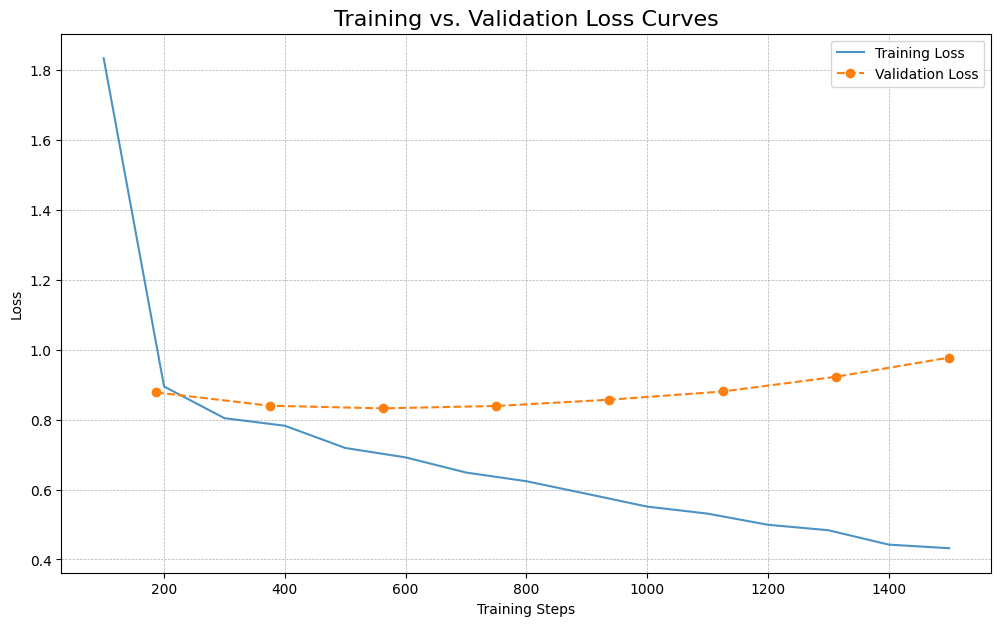

In [ ]:
#
# -------------------------------------------------------------------------------------------------
# 8. PLOT TRAINING & VALIDATION LOSS
# -------------------------------------------------------------------------------------------------
#
import pandas as pd
import matplotlib.pyplot as plt

# The trainer's state holds a log of all training and evaluation steps
log_history = trainer.state.log_history
df = pd.DataFrame(log_history)

# Separate the logs for training and evaluation
# Training logs have a 'loss' key, while evaluation logs have an 'eval_loss' key
train_logs = df[df['loss'].notna()].reset_index(drop=True)
eval_logs = df[df['eval_loss'].notna()].reset_index(drop=True)

# Create the plot
plt.figure(figsize=(12, 7))
plt.plot(train_logs['step'], train_logs['loss'], label='Training Loss', alpha=0.8)
plt.plot(eval_logs['step'], eval_logs['eval_loss'], label='Validation Loss', marker='o', linestyle='--')

# Add titles and labels for clarity
plt.title('Training vs. Validation Loss Curves', fontsize=16)
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [ ]:
#
# -------------------------------------------------------------------------------------------------
# 9. FINAL EVALUATION ON THE TEST SET
# -------------------------------------------------------------------------------------------------
#
import math

print("\n--- Starting Final Evaluation on Test Set ---")

# 1. Run prediction on the test set using the best model
# The trainer automatically loads the best model checkpoint at the end of training.
test_results = trainer.predict(
    test_dataset=processed_datasets["test"],
    num_beams=5  # Use beam search for higher quality captions
)


# 2. Calculate Perplexity from the test loss
# The test_results object contains metrics calculated on the test set
test_metrics = test_results.metrics
test_loss = test_metrics.get("test_loss")

if test_loss:
    perplexity = math.exp(test_loss)
    print(f"\n🌀 Test Set Perplexity: {perplexity:.4f}")
else:
    print("\nTest loss not available to calculate perplexity.")


# 3. Decode predictions and prepare references
# Decode the generated token IDs into text
predictions = tokenizer.batch_decode(test_results.predictions, skip_special_tokens=True)

# Prepare all reference captions. For the test set, we compare against all available ground truths.
references = [raw_datasets['test'][i]['captions'] for i in range(len(test_results.label_ids))]


# 4. Compute all metrics against the full set of references
print("\nCalculating Final Metrics...")

# Format data for COCO-style metrics (CIDEr, SPICE, ROUGE)
preds_coco, refs_coco = format_for_coco_eval(predictions, references)

# Compute scores
bleu_score = bleu.compute(predictions=predictions, references=references)
meteor_score = meteor.compute(predictions=predictions, references=references)
rouge_score, _ = rouge.compute_score(refs_coco, preds_coco)
cider_score, _ = cider.compute_score(refs_coco, preds_coco)
spice_score, _ = spice.compute_score(refs_coco, preds_coco)


# 5. Print the final results table
print("\n\n--- Final Test Set Scores ---")
print("-----------------------------")
print(f"  - BLEU-1:  {bleu_score['precisions'][0]:.4f}")
print(f"  - BLEU-2:  {bleu_score['precisions'][1]:.4f}")
print(f"  - BLEU-3:  {bleu_score['precisions'][2]:.4f}")
print(f"  - BLEU-4:  {bleu_score['precisions'][3]:.4f}")
print("-----------------------------")
print(f"  - METEOR:  {meteor_score['meteor']:.4f}")
print(f"  - ROUGE_L: {rouge_score:.4f}")
print(f"  - CIDEr:   {cider_score:.4f}")
print(f"  - SPICE:   {spice_score:.4f}")
print("-----------------------------")

# Log final metrics to WandB as a summary
if wandb.run:
    wandb.run.summary["test_perplexity"] = perplexity
    wandb.run.summary["test_bleu_4"] = bleu_score['precisions'][3]
    wandb.run.summary["test_cider"] = cider_score
    wandb.run.summary["test_meteor"] = meteor_score['meteor']
    wandb.run.summary["test_rouge_l"] = rouge_score


--- Starting Final Evaluation on Test Set ---


Parsing reference captions
Initiating Stanford parsing pipeline
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator tokenize
[main] INFO edu.stanford.nlp.pipeline.TokenizerAnnotator - TokenizerAnnotator: No tokenizer type provided. Defaulting to PTBTokenizer.
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ssplit
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator parse
[main] INFO edu.stanford.nlp.parser.common.ParserGrammar - Loading parser from serialized file edu/stanford/nlp/models/lexparser/englishPCFG.ser.gz ... 
done [0.4 sec].
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator lemma
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ner
Loading classifier from edu/stanford/nlp/models/ner/english.all.3class.distsim.crf.ser.gz ... done [1.0 sec].
Loading classifier from edu/stanford/nlp/models/ner/english.muc.7class.distsim.crf.ser.gz ... done [0.5 sec].
Loading classif

SPICE evaluation took: 11.23 s

🌀 Test Set Perplexity: 2.2401

Calculating Final Metrics...


Parsing reference captions
Initiating Stanford parsing pipeline
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator tokenize
[main] INFO edu.stanford.nlp.pipeline.TokenizerAnnotator - TokenizerAnnotator: No tokenizer type provided. Defaulting to PTBTokenizer.
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ssplit
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator parse
[main] INFO edu.stanford.nlp.parser.common.ParserGrammar - Loading parser from serialized file edu/stanford/nlp/models/lexparser/englishPCFG.ser.gz ... 
done [0.4 sec].
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator lemma
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ner
Loading classifier from edu/stanford/nlp/models/ner/english.all.3class.distsim.crf.ser.gz ... done [1.0 sec].
Loading classifier from edu/stanford/nlp/models/ner/english.muc.7class.distsim.crf.ser.gz ... done [0.5 sec].
Loading classif

SPICE evaluation took: 15.62 s


--- Final Test Set Scores ---
-----------------------------
  - BLEU-1:  0.5693
  - BLEU-2:  0.2656
  - BLEU-3:  0.1160
  - BLEU-4:  0.0508
-----------------------------
  - METEOR:  0.4164
  - ROUGE_L: 0.4919
  - CIDEr:   0.4333
  - SPICE:   0.1413
-----------------------------



--- Generating 3 Qualitative Examples and Logging to WandB ---


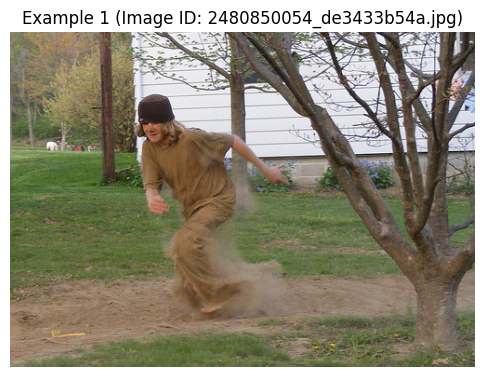

🤖 Generated Caption: a boy in a blue shirt is jumping in the air 

📖 Reference Captions:
  - a boy is kicking up dust as he runs in the dirt by a tree 
  - a boy wearing brown running in dirt 
  - a dirty boy runs through the dirt 
  - a dusty boy runs along a dirt path through the grass 
  - a teenage boy runs through the dirt near a house in the country 



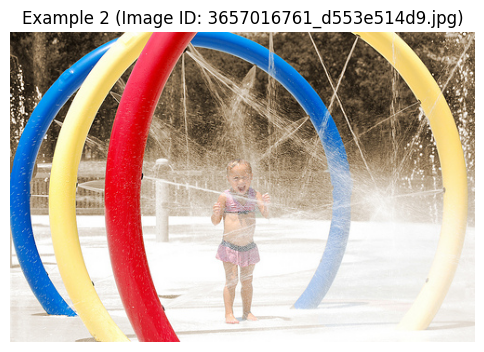

🤖 Generated Caption: a little girl in a pink shirt is jumping in a playground sprinkler 

📖 Reference Captions:
  - a child at a water park is sprayed from all sides by a ring of water 
  - a child in a pink and black bathing suit walks through water mist from colored rings 
  - a young girl stands under three large rings that shoot water in a water park 
  - colorful rings spraying water at little girl wearing swimsuit 
  - the little girl in her bathing suit stands near the sprinkers and squeals 



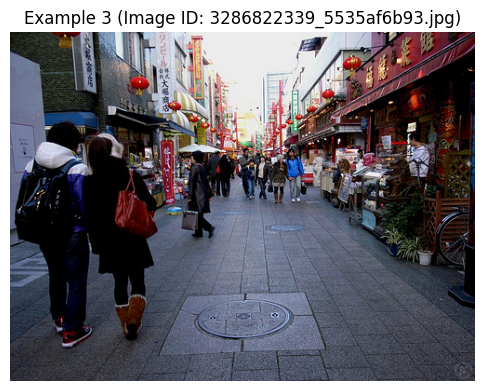

🤖 Generated Caption: a group of people are walking down a street carrying bags 

📖 Reference Captions:
  - a busy city street with many people walking along it 
  - a couple walk to the side of a crowded walkway 
  - chinese market street in the winter time 
  - people walk down a paved street that has red lanterns hung from the buildings 
  - people walking down street lined with chinese lanterns 


✅ Successfully logged qualitative examples to WandB.


In [ ]:
#
# -------------------------------------------------------------------------------------------------
# 10. QUALITATIVE EXAMPLES & WANDB LOGGING
# -------------------------------------------------------------------------------------------------
#
import random
import matplotlib.pyplot as plt
from PIL import Image
import wandb

def generate_caption(image_path, model, processor, tokenizer, device):
    """Generates a caption for a single image using the trained model."""
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
    generated_ids = model.generate(pixel_values=pixel_values)
    caption = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    return caption

# Use the trained model from the trainer for inference
inference_model = trainer.model
print(f"\n--- Generating 3 Qualitative Examples and Logging to WandB ---")

# 1. Create a wandb.Table for logging examples
examples_table = wandb.Table(columns=["id", "image", "generated_caption", "reference_captions"])

# --- FIX: Ensure we only sample from examples that have ground truth captions ---
# First, find all indices in the test set that have a non-empty list of captions.
valid_indices = [
    i for i, item in enumerate(raw_datasets["test"])
    if item.get("captions") and len(item["captions"]) > 0
]

# Randomly sample 3 indices from this guaranteed-valid list.
if len(valid_indices) >= 3:
    sample_indices = random.sample(valid_indices, 3)
else:
    print(f"Warning: Found fewer than 3 examples with captions. Displaying {len(valid_indices)} examples.")
    sample_indices = valid_indices
# -------------------------------------------------------------------------------


# Loop through the guaranteed-valid indices to generate and display examples
for i, idx in enumerate(sample_indices):
    # Get the data for the selected example
    example_image_path = raw_datasets["test"][idx]["image_path"]
    true_captions = raw_datasets["test"][idx]["captions"]
    image = Image.open(example_image_path)

    # Generate a caption with our model
    generated_caption = generate_caption(example_image_path, inference_model, processor, tokenizer, device)

    # Add the example to the wandb.Table
    examples_table.add_data(
        idx,
        wandb.Image(image),
        generated_caption,
        "\n".join(true_captions)
    )

    # Display the results directly in the notebook
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Example {i+1} (Image ID: {os.path.basename(example_image_path)})")
    plt.show()

    print(f"🤖 Generated Caption: {generated_caption}")
    print(f"\n📖 Reference Captions:")
    for ref in true_captions:
        print(f"  - {ref}")
    print("\n" + "="*40)

# Log the completed table to your active WandB run
if wandb.run:
    wandb.log({"qualitative_examples": examples_table})
    print("\n✅ Successfully logged qualitative examples to WandB.")

In [ ]:
#
# -------------------------------------------------------------------------------------------------
# 11. FINISH WEIGHTS & BIASES RUN
# -------------------------------------------------------------------------------------------------
#
# Check if a WandB run is active before trying to finish it.
if wandb.run:
    print("🧹 Finishing the Weights & Biases run...")
    wandb.finish()
    print("\n✅ Run finished and all data saved.")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


🧹 Finishing the Weights & Biases run...


eval/BLEU-1,▁▃█▇█▆█▇
eval/BLEU-2,▁▄█▇█▇▇▇
eval/BLEU-3,▁▅█▆██▆▇
eval/BLEU-4,▁▅█▅▆▆▃▃
eval/CIDEr,▁▄█▇█▇▇▆
eval/METEOR,▁▅▇▇██▇▆
eval/ROUGE_L,▁▄█▇█▇▇▆
eval/SPICE,▁▅██████
eval/loss,▃▁▁▁▂▃▅█
eval/runtime,█▅▁▇▆▇▆▂
eval/samples_per_second,▁▃█▂▃▂▃▇



✅ Run finished and all data saved.


In [4]:
#
# -------------------------------------------------------------------------------------------------
# 12. STREAMLIT APPLICATION FOR INTERACTIVE CAPTIONING
# -------------------------------------------------------------------------------------------------
#
import os
from transformers import GenerationConfig

# --- 1. Save the fine-tuned model and create a GenerationConfig ---

streamlit_model_path = "./streamlit_app_model"

# Create a GenerationConfig object with our desired parameters
generation_config = GenerationConfig.from_pretrained(
    cfg.decoder_name,
    max_length=cfg.max_length,
    early_stopping=True,
    num_beams=5,
    length_penalty=2.0,
    no_repeat_ngram_size=3,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
    decoder_start_token_id=tokenizer.bos_token_id,
)

# Save the model, tokenizer, processor, and the new generation_config
trainer.save_model(streamlit_model_path)
tokenizer.save_pretrained(streamlit_model_path)
processor.save_pretrained(streamlit_model_path)
generation_config.save_pretrained(streamlit_model_path)

print(f"✅ Fine-tuned model and generation config saved to {streamlit_model_path}")


# --- 2. Install Streamlit (with fix for blinker error) ---
!pip install -q streamlit --ignore-installed blinker


# --- 3. Write the Streamlit App to a Python file (standard method) ---

app_code = """
import streamlit as st
from PIL import Image as PILImage
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer, GenerationConfig
import torch
import types

# --- Page Configuration ---
st.set_page_config(
    page_title="Image Caption Generator",
    page_icon="🖼️",
    layout="centered",
    initial_sidebar_state="expanded"
)

# --- App Title and Description ---
st.title("🖼️ AI Image Caption Generator")
st.markdown(
    '''
    Welcome! This application uses a fine-tuned **ViT-GPT2** model to generate
    captions for your images. Upload an image and see the AI in action.
    '''
)
st.markdown("---")

# --- Model Loading ---
@st.cache_resource(show_spinner="Loading the fine-tuned model...")
def load_model():
    model_path = "./streamlit_app_model"
    model = VisionEncoderDecoderModel.from_pretrained(model_path)
    feature_extractor = ViTImageProcessor.from_pretrained(model_path)
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    # Load the dedicated generation config
    generation_config = GenerationConfig.from_pretrained(model_path)

    # --- FIX: Monkey-patch the _reorder_cache method for beam search ---
    # This is a known workaround for a missing function in some library versions.
    model.decoder._reorder_cache = types.MethodType(
        model.decoder.transformer._reorder_cache, model.decoder
    )
    # --------------------------------------------------------------------

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    return model, feature_extractor, tokenizer, device, generation_config

model, feature_extractor, tokenizer, device, generation_config = load_model()

# --- Caption Generation Logic ---
def generate_caption_for_image(image):
    '''Takes a PIL image and returns a generated caption.'''
    if image.mode != "RGB":
        image = image.convert("RGB")

    pixel_values = feature_extractor(images=[image], return_tensors="pt").pixel_values.to(device)

    # Use the loaded generation_config
    output_ids = model.generate(pixel_values, generation_config=generation_config)

    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return caption.strip()

# --- UI for Image Upload and Caption Display ---
uploaded_file = st.file_uploader(
    "Choose an image to caption...",
    type=['png', 'jpg', 'jpeg'],
    accept_multiple_files=False
)

if uploaded_file is not None:
    image = PILImage.open(uploaded_file)
    st.image(image, caption='Your Uploaded Image', use_column_width=True)

    with st.spinner("🤖 Generating caption..."):
        caption = generate_caption_for_image(image)
        st.success("Caption Generated!")
        st.markdown(f"### 💬 **Caption:** {caption}")
else:
    st.info("Please upload an image to get started.")

# --- Sidebar Content ---
with st.sidebar:
    st.header("About the Model")
    st.markdown(
        '''
        This demo uses a **Vision Transformer (ViT)** as the image encoder and a **GPT-2** model
        as the text decoder. The model was fine-tuned on the dataset specified in the notebook.
        '''
    )
"""

# Write the code to the app.py file
with open("app.py", "w") as f:
    f.write(app_code)

print("✅ Streamlit app code written to app.py")

NameError: name 'tokenizer' is not defined

In [5]:
#Get Public IP Address in Google Colab
!wget -q -O - ipv4.icanhazip.com

34.87.13.179


In [ ]:
#Google Colab users can run the following command to start the Streamlit app:
#!streamlit run app.py --server.port 8501 --server.address 0.0
# If you're running this in a local environment, you can start the app with:
#!streamlit run app.py
# For RunPod users, you can run the following command to start the Streamlit app:
#!streamlit run app.py --server.port 8501 --server.address 0.0

# Check which port is exposed as the HTTP Port on your RunPod pod page (e.g., 3001)
POD_HTTP_PORT=7777

# Run streamlit in the background and save logs to 'streamlit.log'
!streamlit run app.py --server.port $POD_HTTP_PORT --server.address 0.0.0.0 > streamlit.log 2>&1

# Give the server a moment to start
import time
time.sleep(5)

print(f"✅ Streamlit app is running in the background on port {POD_HTTP_PORT}.")
print("Please open the public URL for your pod's HTTP service in a new browser tab to view the app.")

✅ Streamlit app is running in the background on port 7777.
Please open the public URL for your pod's HTTP service in a new browser tab to view the app.


In [ ]:
import subprocess
import os

# Set the port to match your RunPod HTTP Service port
POD_HTTP_PORT = 7777
command = f"streamlit run app.py --server.port {POD_HTTP_PORT} --server.address 0.0.0.0"

# Use subprocess.Popen to run the command in the background
# Logs will be saved to 'streamlit.log'
with open("streamlit.log", "w") as log_file:
    process = subprocess.Popen(command, shell=True, stdout=log_file, stderr=log_file)

print(f"✅ Streamlit app launched as a background process (PID: {process.pid}).")
print(f"   - Logs are being saved to streamlit.log")
print(f"   - To stop the server, you may need to interrupt the kernel.")

✅ Streamlit app launched as a background process (PID: 36178).
   - Logs are being saved to streamlit.log
   - To stop the server, you may need to interrupt the kernel.


Bad pipe message: %s [b'-7777.proxy.runpod.net\r\nx-forwarded-for: 183.83.39.166, 172.68.166.138\r\nupgrade-insecure-requests: 1\r\nsec-fetch-user: ']
Bad pipe message: %s [b'\r\nsec-fetch-site: same-origin\r\nsec-fetch-mode: navigate\r\nsec-f', b'ch-dest: document\r\nsec-ch-ua-platform: "macOS"\r\nsec-ch-ua-mobile: ?0\r\nsec-ch-ua: "Not)A;Brand";v="8"']
Bad pipe message: %s [b'"Chromium";v="138", "Microsoft Edge";v="138']
Bad pipe message: %s [b'\nreferer: https://zd87pqvciuhiw4-', b'77.proxy.runpod.net/?folder=/workspace\r\npriority: u=0,', b'\r\ncookie: _streamlit_xsrf=2|1ee', b'215|80ae4a55872ebfc64b25469451791428|1753431039\r\ncf-vis']
Bad pipe message: %s [b'or: {"scheme":"https"}\r\ncf-ray: 964a498918b82e85-HYD\r\ncf-ipcountry: IN\r\ncf-connecting-ip: 183.83.39.166\r']
Bad pipe message: %s [b'dn-loop: ', b'oudflare; loops=1\r\naccept-language: en-IN,en-GB;q=0.9,en;q=0.8,en-US;q=0.7\r\naccept-encoding: gzip,']
Bad pipe message: %s [b'r\r\naccept: text/html,applicatio']
Bad pipe m

In [ ]:
# Find the path to your best checkpoint (replace 'checkpoint-XXXX' if different)
BEST_MODEL_PATH="./streamlit_app_model" # Example path
APP_FILE="app.py"
OUTPUT_ZIP="streamlit_app_bundle.zip"

# Zip the best model folder and the app.py file
!zip -r $OUTPUT_ZIP $BEST_MODEL_PATH $APP_FILE

print(f"✅ Created {OUTPUT_ZIP}. Please download this file from the Jupyter file browser.")

  adding: streamlit_app_model/ (stored 0%)
  adding: streamlit_app_model/preprocessor_config.json (deflated 47%)
  adding: streamlit_app_model/training_args.bin (deflated 52%)
  adding: streamlit_app_model/merges.txt (deflated 53%)
  adding: streamlit_app_model/vocab.json (deflated 68%)
  adding: streamlit_app_model/special_tokens_map.json (deflated 74%)
  adding: streamlit_app_model/tokenizer_config.json (deflated 55%)
  adding: streamlit_app_model/model.safetensors (deflated 7%)
  adding: streamlit_app_model/generation_config.json (deflated 44%)
  adding: streamlit_app_model/config.json (deflated 76%)
  adding: app.py (deflated 57%)
✅ Created streamlit_app_bundle.zip. Please download this file from the Jupyter file browser.


In [ ]:
"""# Unzip the bundled files
!unzip -q streamlit_app_bundle.zip

# The unzipped folder will have a long name, let's rename it for simplicity
# First, find the folder name (it will start with './streamlit_app_model/')
import os
unzipped_folder_name = [d for d in os.listdir('.') if d.startswith('results')][0]
os.rename(unzipped_folder_name, 'streamlit_app_model')

print("✅ Files unzipped and model folder renamed to 'streamlit_app_model'.")

# Install required libraries
!pip install -q streamlit transformers torch"""